<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/FeatureSelection_ALL_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('BankChurners.csv')
df.shape

(10127, 23)

In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(10127, 23)

In [ ]:
df.drop(columns=['CLIENTNUM','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],inplace=True)
df.shape


(10127, 20)

In [ ]:
X = df.drop(columns=['Attrition_Flag'])
Y = df['Attrition_Flag']
X.shape,Y.shape

((10127, 19), (10127,))

In [ ]:
Y.unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [ ]:
Y.replace({'Existing Customer':0,'Attrited Customer':1},inplace=True)
Y.unique()

/tmp/ipykernel_21361/1324299039.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y.replace({'Existing Customer':0,'Attrited Customer':1},inplace=True)


array([0, 1])

In [ ]:
Y.value_counts(normalize=True)

,proportion
Attrition_Flag,
0,0.83934
1,0.16066


In [ ]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(10127, 37)

In [ ]:
continous_col = X.columns[X.nunique()>15]
continous_col

Index(['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [ ]:
# train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X_ohe,Y,test_size=0.3,random_state=7,stratify=Y) # whenever a classification problem -- use startify

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((7088, 37), (3039, 37), (7088,), (3039,))

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train[continous_col] = sc.fit_transform(X_train[continous_col])
X_test[continous_col] = sc.fit_transform(X_test[continous_col])

In [ ]:
X_train[continous_col].mean()

,0
Customer_Age,4.247919e-16
Months_on_book,2.135237e-16
Credit_Limit,1.363344e-16
Total_Revolving_Bal,-7.017211e-18
Avg_Open_To_Buy,1.253073e-17
Total_Amt_Chng_Q4_Q1,6.215244e-17
Total_Trans_Amt,-1.268110e-16
Total_Trans_Ct,-2.390864e-16
Total_Ct_Chng_Q4_Q1,3.448458e-16
Avg_Utilization_Ratio,-1.601428e-16


Kernel PCA


In [ ]:
from sklearn.decomposition import KernelPCA

In [ ]:
kpca = KernelPCA(kernel='rbf',random_state=7)
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

# 7087 equations(components) created in fit-transform process on training data , and the model can only use th equations
#  it learned on the training data, hence even on ttest data it created 7087 columns.
# there is no learning on test data

X_train_kpca.shape,X_test_kpca.shape

#kpca.eigenvalues_.shape

((7088, 7087), (3039, 7087))

Doing PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95,random_state=7) #generate all possible components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
X_train_pca.shape,X_test_pca.shape

((7088, 19), (3039, 19))

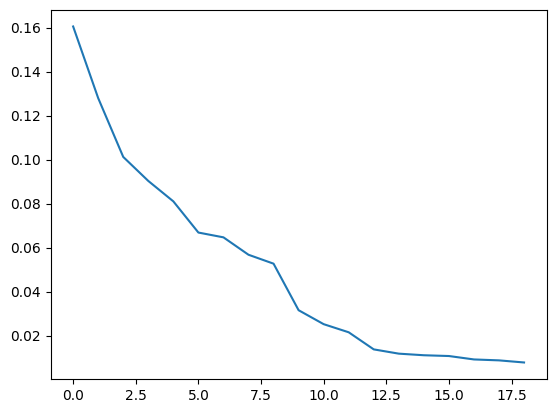

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)

In [ ]:
pca.explained_variance_ratio_

array([0.16050153, 0.12793481, 0.10121645, 0.09030032, 0.08101999,
       0.06684718, 0.06467227, 0.05676268, 0.05270704, 0.03155677,
       0.02521588, 0.0215244 , 0.01375282, 0.01181354, 0.01108888,
       0.01073555, 0.00918128, 0.00876083, 0.0078034 ])

Using RFE (Recursive Feature Selection)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [ ]:
rfe = RFE(LogisticRegression(random_state=7),verbose=2)

rfe.fit(X_train,Y_train)
print(rfe.ranking_)

Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 29 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 28 features.


...

Fitting estimator with 27 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 26 features.
Fitting estimator with 25 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
[ 5  3 20  1  1  1  1  1 13 16  1  1  1 14  1  1  9 19 11 10  2 12 18 15
  1  4 17  1  1  6  1  7  8  1  1  1  1]


In [ ]:
X_train.columns[rfe.ranking_ == 1] ## features recommended by RFE

Index(['Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Gender_F',
       'Gender_M', 'Marital_Status_Married', 'Income_Category_$120K +',
       'Income_Category_$40K - $60K', 'Income_Category_$80K - $120K',
       'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_Platinum',
       'Card_Category_Silver'],
      dtype='object')

In [ ]:
for col,rank in zip(X_train.columns,rfe.ranking_):
  print(col,rank)

Customer_Age 5
Dependent_count 3
Months_on_book 20
Total_Relationship_Count 1
Months_Inactive_12_mon 1
Contacts_Count_12_mon 1
Credit_Limit 1
Total_Revolving_Bal 1
Avg_Open_To_Buy 13
Total_Amt_Chng_Q4_Q1 16
Total_Trans_Amt 1
Total_Trans_Ct 1
Total_Ct_Chng_Q4_Q1 1
Avg_Utilization_Ratio 14
Gender_F 1
Gender_M 1
Education_Level_College 9
Education_Level_Doctorate 19
Education_Level_Graduate 11
Education_Level_High School 10
Education_Level_Post-Graduate 2
Education_Level_Uneducated 12
Education_Level_Unknown 18
Marital_Status_Divorced 15
Marital_Status_Married 1
Marital_Status_Single 4
Marital_Status_Unknown 17
Income_Category_$120K + 1
Income_Category_$40K - $60K 1
Income_Category_$60K - $80K 6
Income_Category_$80K - $120K 1
Income_Category_Less than $40K 7
Income_Category_Unknown 8
Card_Category_Blue 1
Card_Category_Gold 1
Card_Category_Platinum 1
Card_Category_Silver 1


In [ ]:
selected_col = X_train.columns[rfe.ranking_ == 1]
selected_col

Index(['Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Gender_F',
       'Gender_M', 'Marital_Status_Married', 'Income_Category_$120K +',
       'Income_Category_$40K - $60K', 'Income_Category_$80K - $120K',
       'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_Platinum',
       'Card_Category_Silver'],
      dtype='object')

In [ ]:
X_train_rfe = X_train.loc[:,selected_col]
X_test_rfe = X_test.loc[:,selected_col]

X_train_rfe.shape,X_test_rfe.shape,


((7088, 18), (3039, 18))

Decision Tree using Gini Index

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(criterion='gini',class_weight='balanced',random_state=7)

dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [ ]:
fi = zip(X_train.columns,dt.feature_importances_)

for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

Total_Trans_Ct 0.4370717956080788
Total_Trans_Amt 0.18469125596809555
Total_Revolving_Bal 0.09256365715486943
Total_Ct_Chng_Q4_Q1 0.062326951962327244
Total_Relationship_Count 0.05296372005210665
Total_Amt_Chng_Q4_Q1 0.04923375881705681
Customer_Age 0.02226774323240459
Credit_Limit 0.016112803470415975
Avg_Open_To_Buy 0.011573764246454798
Months_on_book 0.010115615799537006
Contacts_Count_12_mon 0.00993388980238585
Months_Inactive_12_mon 0.008373842255208588
Avg_Utilization_Ratio 0.008059157763627244
Dependent_count 0.007101291570407155
Marital_Status_Married 0.0042535400623745735
Income_Category_$40K - $60K 0.0034741267345907326
Income_Category_$80K - $120K 0.002801248962349818
Marital_Status_Divorced 0.0021812345177598734
Marital_Status_Unknown 0.00214568256095734
Gender_M 0.001946284044892295
Card_Category_Platinum 0.0017291832232415295
Education_Level_Uneducated 0.0014569142906411781
Income_Category_Unknown 0.0014385655570807912
Income_Category_$60K - $80K 0.001349980646442136
Educ

In [ ]:
X_train.columns[dt.feature_importances_ > 0.5 * dt.feature_importances_.mean()]

Index(['Customer_Age', 'Total_Relationship_Count', 'Contacts_Count_12_mon',
       'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1'],
      dtype='object')

In [ ]:
X_train_dt = X_train.loc[:,selected_col]
X_test_dt = X_test.loc[:,selected_col]

X_train_dt.shape,X_test_dt.shape

((7088, 18), (3039, 18))

Using Entropy Criteria

In [ ]:
dt = DecisionTreeClassifier(criterion='entropy',class_weight='balanced',random_state=7)

dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=7)

In [ ]:
fi = zip(X_train.columns,dt.feature_importances_)

for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

Total_Trans_Ct 0.3866288451493934
Total_Trans_Amt 0.22918596811579237
Total_Revolving_Bal 0.09514070824571338
Total_Ct_Chng_Q4_Q1 0.05617581803987172
Total_Amt_Chng_Q4_Q1 0.05446686519379511
Total_Relationship_Count 0.04854303555332101
Customer_Age 0.021099531405718828
Avg_Open_To_Buy 0.019482890246921323
Credit_Limit 0.016048005053582153
Contacts_Count_12_mon 0.013683424935831938
Months_Inactive_12_mon 0.012650950103688075
Months_on_book 0.012000007473618382
Avg_Utilization_Ratio 0.008806925574980915
Dependent_count 0.00540533682754335
Marital_Status_Married 0.00413519414795036
Education_Level_Post-Graduate 0.002497156864394393
Income_Category_$60K - $80K 0.0022275905231433947
Income_Category_$40K - $60K 0.0013696559370033339
Marital_Status_Single 0.0012897985295978686
Education_Level_High School 0.0012164939642955997
Marital_Status_Divorced 0.0011204182069770344
Income_Category_Less than $40K 0.001118786567494751
Gender_M 0.0010892148170102138
Education_Level_Uneducated 0.00104362177